<a href="https://colab.research.google.com/github/HildaKholifah/IntroDPI_IF6A_0706/blob/main/Pengolahan_CItra_P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import cv2
import numpy as plt
import matplotlib.pyplot as plt

Tipe data: <class 'numpy.ndarray'>
Shape    : (450, 450, 3)
Dtype    : uint8

Artinya:
 Tinggi   = 450 piksel
 Lebar    = 450 piksel
 Channel  = 3 (BGR)
Total piksel:  202500


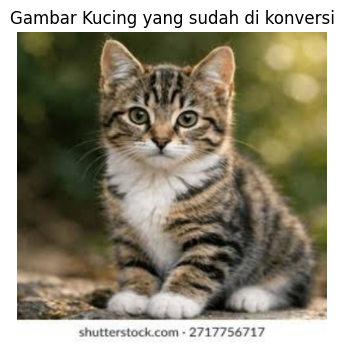

In [ ]:
# Baca gambar dari file
#cv2.imread() mengembalikan array NumPy!
img_bgr = cv2.imread('/content/drive/MyDrive/kucing.jpg')

# Resize agar tidak terlalu besar
img_bgr = cv2.resize(img_bgr, (450, 450))

# Cek tipe data: ternyata sudah array NumPy!
print("Tipe data:", type(img_bgr))     #numpy.ndarray
print("Shape    :", img_bgr.shape)     #(450, 300, 3)
print("Dtype    :", img_bgr.dtype)     # uint8

print()
print("Artinya:")
print(f" Tinggi   = {img_bgr.shape[0]} piksel")
print(f" Lebar    = {img_bgr.shape[1]} piksel")
print(f" Channel  = {img_bgr.shape[2]} (BGR)")

# Konversi BGR RGB untuk ditampilkan di Matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Total piksel: ", img_bgr.shape[0] * img_bgr.shape[1])

#Tampilkan gambar
plt.figure(figsize=(4, 6))
plt.imshow(img_rgb)
plt.title('Gambar Kucing yang sudah di konversi')
plt.axis('off')
plt.show()

=== MATRIKS f(x,y) Area 8x8 Piksel ===
Setiap angka nilai intensitas 1 piksel (0=hitam, 255=putih)

[[150 147 144 142 139 139 139 141]
 [153 150 147 145 142 142 142 144]
 [155 153 150 147 145 145 145 147]
 [158 155 152 150 148 148 148 150]
 [159 157 154 152 149 149 150 151]
 [160 157 154 151 148 149 150 152]
 [159 155 152 149 146 147 149 153]
 [155 154 153 152 152 153 156 159]] 

Contoh baca: f(180, 200) = 150
Contoh baca: f(181, 201) = 150

Resolusi (Tinggi x Lebar): (450, 450)
Total pixel   : 202500
Total size KB : 197.75 KB
Total size MB : 0.19 MB


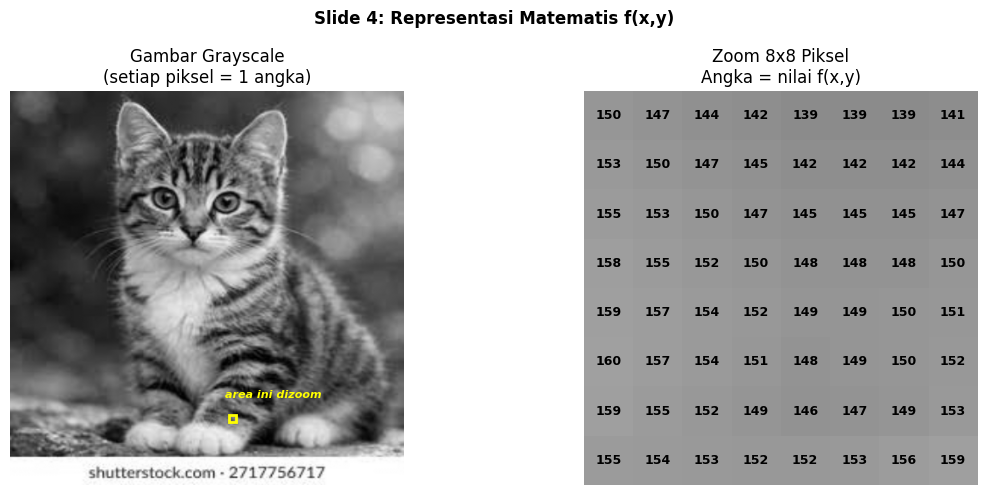

In [ ]:
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Ambil area kecil 8x8 piksel dari tengah gambar (area kaki)
area_kecil = img_gray[200:208, 180:188]

print("=== MATRIKS f(x,y) Area 8x8 Piksel ===")
print("Setiap angka nilai intensitas 1 piksel (0=hitam, 255=putih)\n")
print(area_kecil, "\n")

print("Contoh baca:", f"f(180, 200) = {img_gray[200, 180]}")
print("Contoh baca:", f"f(181, 201) = {img_gray[201, 181]}\n")

# Menghitung total jumlah piksel pada gambar (Tinggi x Lebar)
total_pixel = img_gray.shape[0] * img_gray.shape[1]

# Menghitung ukuran KiloByte (KB) dan menghitung ukuran MegaByte (MB)
konversi_kb = total_pixel / 1024
konversi_mb = konversi_kb / 1024

print("Resolusi (Tinggi x Lebar):", img_gray.shape)
print("Total pixel   :", total_pixel)
print("Total size KB :", f"{konversi_kb:.2f} KB")
print("Total size MB :", f"{konversi_mb:.2f} MB")

# Tampilkan area kecil dengan nilai angkanya
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Kiri: gambar grayscale penuh
axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Gambar Grayscale\n(setiap piksel = 1 angka)')
axes[0].axis('off')

# tandai area yang kita zoom
import matplotlib.patches as patches
rect = patches.Rectangle((250,370), 8, 8, linewidth=2, edgecolor='yellow', facecolor='none')
axes[0].add_patch(rect)
axes[0].text(245, 350, 'area ini dizoom', color='yellow', fontsize=8, fontweight='bold', fontstyle='italic')

# kanan: tampilkan nilai angka pada setiap piksel
axes[1].imshow(area_kecil, cmap='gray', vmin=0, vmax=255)
for i in range(8):
    for j in range(8):
        nilai = area_kecil[i, j]
        warna_teks = 'white' if nilai < 128 else 'black'
        axes[1].text(j, i, str(nilai), ha='center', va='center', fontsize=9, color=warna_teks, fontweight='bold')
axes[1].set_title('Zoom 8x8 Piksel\nAngka = nilai f(x,y)')
axes[1].axis('off')

plt.suptitle('Slide 4: Representasi Matematis f(x,y)', fontweight='bold')
plt.tight_layout()
plt.show()

=== MATRIKS f(x,y) Area 8x8 Piksel ===
Setiap pixel berisi nilai (R, G, B)

[[[154 155 141]
  [152 153 136]
  [134 134 115]
  [105 104  85]
  [ 77  75  55]
  [ 56  52  32]
  [ 39  34  16]
  [ 27  21   9]]

 [[146 149 133]
  [147 149 132]
  [130 132 112]
  [113 115  93]
  [ 95  95  74]
  [ 71  70  47]
  [ 55  52  31]
  [ 50  45  26]]

 [[ 89  92  76]
  [ 93  97  78]
  [ 88  92  70]
  [ 88  91  69]
  [ 86  88  65]
  [ 71  72  48]
  [ 64  62  39]
  [ 65  61  40]]

 [[ 26  30  15]
  [ 33  37  19]
  [ 42  47  26]
  [ 58  62  39]
  [ 71  74  50]
  [ 68  70  45]
  [ 69  68  45]
  [ 76  72  51]]

 [[  8  12   4]
  [ 19  24  11]
  [ 36  43  20]
  [ 53  59  34]
  [ 68  72  47]
  [ 70  73  47]
  [ 73  74  49]
  [ 76  74  51]]

 [[  8  14   4]
  [ 24  31  15]
  [ 46  55  31]
  [ 62  69  43]
  [ 75  80  54]
  [ 79  83  56]
  [ 80  82  56]
  [ 77  76  53]]

 [[ 21  31  11]
  [ 44  54  29]
  [ 71  81  54]
  [ 82  90  63]
  [ 90  96  68]
  [ 92  97  70]
  [ 89  92  66]
  [ 80  80  56]]

 [[ 32  42  19

/tmp/ipykernel_1217/1583448798.py:32: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = patches.Rectangle((180, 118), 8, 8, linewidth=2, edgecolor='red', color='red')


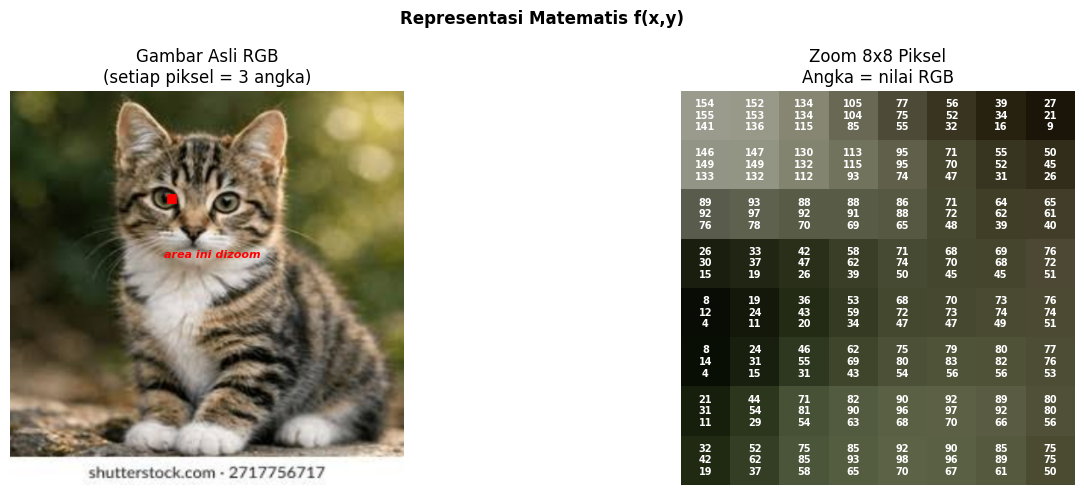

In [ ]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Ambil area kecil 8x8 piksel dari tengah gambar (area mata)
area_kecil = img_rgb[118:126, 180:188]

print("=== MATRIKS f(x,y) Area 8x8 Piksel ===")
print("Setiap pixel berisi nilai (R, G, B)\n")
print(area_kecil, "\n")

# Menghitung total jumlah piksel pada gambar (Tinggi x Lebar)
total_pixel = img_rgb.shape[0] * img_rgb.shape[1]

# 2. Menghitung ukuran KiloByte (KB) dan menghitung ukuran MegaByte (MB)
konversi_kb = (total_pixel * 3) / 1024
konversi_mb = konversi_kb / 1024

print("Resolusi (Tinggi x Lebar x Channel):", img_rgb.shape)
print("Total pixel   :", total_pixel)
print("Total size KB :", f"{konversi_kb:.2f} KB")
print("Total size MB :", f"{konversi_mb:.2f} MB\n")

# Tampilkan area kecil dengan nilai angkanya
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# Kiri: gambar RGB penuh
axes[0].imshow(img_rgb)
axes[0].set_title('Gambar Asli RGB\n(setiap piksel = 3 angka)')
axes[0].axis('off')

# tandai area yang kita zoom
import matplotlib.patches as patches
rect = patches.Rectangle((180, 118), 8, 8, linewidth=2, edgecolor='red', color='red')
axes[0].add_patch(rect)
axes[0].text(175, 190, 'area ini dizoom', color='red', fontsize=8, fontweight='bold', fontstyle='italic')

# kanan: tampilkan nilai angka pada setiap piksel
axes[1].imshow(area_kecil)
for i in range(8):
    for j in range(8):
        r, g, b = area_kecil[i,j]
        text = f"{r}\n{g}\n{b}"
        axes[1].text(j, i, text, ha='center', va='center', fontsize=7, color='white', fontweight='bold')
axes[1].set_title('Zoom 8x8 Piksel\nAngka = nilai RGB')
axes[1].axis('off')

plt.suptitle('Representasi Matematis f(x,y)', fontweight='bold')
plt.tight_layout()
plt.show()